In [ ]:
!pip install ultralytics wandb -q

In [ ]:
from ultralytics import YOLO
import os
import wandb
import wandb.integration.ultralytics.callback as wb_ultralytics_callback

from google.colab import drive
drive.mount('/content/drive')

DATA = "/content/drive/MyDrive/VehicleDataset/data.yaml"
PROJECT = "/content/drive/MyDrive/VehicleDataset/runs"

import yaml

with open(DATA,'r') as f:
    data=yaml.safe_load(f)

print(data)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
{'path': '/content/drive/MyDrive/VehicleDataset', 'train': 'images/train', 'val': 'images/val', 'test': 'images/test', 'names': {0: 'truck', 1: 'bus', 2: 'car', 3: 'bicycle', 4: 'motorbike'}}


# Data Augmentation

Since the dataset contains only 105 images, data augmentation is required to improve generalization.

The following augmentations are applied only to the training dataset:

- Horizontal Flip
- HSV Color Augmentation
- Image Scaling
- Image Translation
- Mosaic Augmentation
- Small Rotation

These transformations increase data diversity while preserving realistic traffic scenes.

In [ ]:
AUGMENT = dict(

    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,
    degrees=5,
    translate=0.10,
    scale=0.50,
    shear=0.0,
    perspective=0.0,
    flipud=0.0,
    fliplr=0.5,
    mosaic=1.0,
    mixup=0.0,
    copy_paste=0.0
    )

### Registering information in wandb

In [ ]:
try:
    from ultralytics.utils import RANK
except Exception:
    RANK = -1

wb_ultralytics_callback.RANK = RANK

from wandb.integration.ultralytics import add_wandb_callback


wandb.finish()
wandb.login()

run = wandb.init(
    project="Vehicle-Detection-YOLOv8",
    name="YOLOv8s",
    job_type="train",
    config={
        "model": "yolov8s.pt",
        "model_size": "small",
        "data": "data.yaml",
        "epochs": 100,
        "imgsz": 640,
        "batch": 16,
        "task": "vehicle detection",
        "architecture": "YOLOv8",
        "framework": "Ultralytics YOLOv8",
    }
)

model = YOLO("yolov8s.pt")

add_wandb_callback(
    model,
    enable_model_checkpointing=True
)

YOLO(
  (model): DetectionModel(
    (model): Sequential(
      (0): Conv(
        (conv): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (1): Conv(
        (conv): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(64, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (2): C2f(
        (cv1): Conv(
          (conv): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(64, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
          (act): SiLU(inplace=True)
        )
        (cv2): Conv(
          (conv): Conv2d(96, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(64, eps=0.001, momentum=0.03, affine=True, track_running_s

# Fine-Tuning YOLOv8 Small

In [ ]:
model_s = YOLO("yolov8s.pt")


results_s = model_s.train(
    data=DATA,
    epochs=50,
    imgsz=640,
    batch=16,
    device=0,

    project=PROJECT,
    name="YOLOv8s",
    verbose=False,
    exist_ok=True,
    **AUGMENT,

    # تنظیمات دقیق Learning Rate
    lr0=0.01,                    
    lrf=0.01,                    
    momentum=0.937,             
    weight_decay=0.0005,         
    warmup_epochs=3.0,         
    warmup_momentum=0.8,         
    warmup_bias_lr=0.1,          
    optimizer='AdamW',           
    cos_lr=True  
)

Ultralytics 8.4.115 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/VehicleDataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=YOLOv8s, nbs=6

In [ ]:
best_s = YOLO("/content/drive/MyDrive/VehicleDataset/runs/YOLOv8s/weights/best.pt")

metrics_s = best_s.val(data=DATA, verbose=False)

print("\n" + "=" * 40)
print("Validation Metrics - YOLOv8s")
print("=" * 40)

# معیارهای کلی
print(f"Precision : {metrics_s.box.mp:.4f}")
print(f"Recall    : {metrics_s.box.mr:.4f}")
print(f"mAP@50    : {metrics_s.box.map50:.4f}")
print(f"mAP@75    : {metrics_s.box.map75:.4f}")
print(f"mAP@50:95 : {metrics_s.box.map:.4f}")

# زمان پردازش
print("\nSpeed:")
for name, value in metrics_s.speed.items():
    print(f"{name:12}: {value:.2f} ms")

# معیار هر کلاس
print("\nPer-Class mAP@50:95")
print("-" * 40)

for class_id, map_value in enumerate(metrics_s.box.maps):
    class_name = best_s.names[class_id]
    print(f"{class_name:20}: {map_value:.4f}")

print("=" * 40)
wandb.finish()

Ultralytics 8.4.115 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,127,519 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.4±0.1 ms, read: 322.4±211.9 MB/s, size: 2862.4 KB)
val: Scanning /content/drive/.shortcut-targets-by-id/1PjgjUh8x94lL3uBqdQ_Y22uI-kaqFJAb/VehicleDataset/labels/val.cache... 15 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 15/15 3.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 1.8it/s 0.6s
                   all         15        146      0.346      0.481       0.49      0.331
Speed: 0.3ms preprocess, 8.2ms inference, 0.0ms loss, 1.0ms postprocess per image
Results saved to /content/runs/detect/val-2

Validation Metrics - YOLOv8s
Precision : 0.3459
Recall    : 0.4810
mAP@50    : 0.4902
mAP@75    : 0.3590
mAP@50:95 : 0.3312

Speed:
preprocess  : 0.30 ms
inference   : 8.16 ms
loss        : 0.00 ms
postprocess :

### Registering information of YOLOv8 Medium  in wandb

In [ ]:
run = wandb.init(
    project="Vehicle-Detection-YOLOv8",
    name="YOLOv8m",
    job_type="train",
    config={
        "model": "yolov8m.pt",
        "model_size": "medium",
        "data": "data.yaml",
        "epochs": 100,
        "imgsz": 640,
        "batch": 16,
        "task": "vehicle detection",
        "architecture": "YOLOv8",
        "framework": "Ultralytics YOLOv8",
    }
)

model = YOLO("yolov8m.pt")

add_wandb_callback(
    model,
    enable_model_checkpointing=True
)

YOLO(
  (model): DetectionModel(
    (model): Sequential(
      (0): Conv(
        (conv): Conv2d(3, 48, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(48, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (1): Conv(
        (conv): Conv2d(48, 96, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(96, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (2): C2f(
        (cv1): Conv(
          (conv): Conv2d(96, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(96, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
          (act): SiLU(inplace=True)
        )
        (cv2): Conv(
          (conv): Conv2d(192, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(96, eps=0.001, momentum=0.03, affine=True, track_running_

# Fine-Tuning YOLOv8 Medium

In [ ]:
model_m = YOLO("yolov8m.pt")


results_m = model_m.train(
    data=DATA,
    epochs=50,
    imgsz=640,
    batch=16,
    device=0,

    project=PROJECT,
    name="YOLOv8m",
    verbose=False,
    exist_ok=True,
    **AUGMENT,

    # تنظیمات دقیق Learning Rate
    lr0=0.01,                    
    lrf=0.01,                    
    momentum=0.937,             
    weight_decay=0.0005,         
    warmup_epochs=3.0,         
    warmup_momentum=0.8,         
    warmup_bias_lr=0.1,          
    optimizer='AdamW',           
    cos_lr=True  
)

Ultralytics 8.4.115 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/VehicleDataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=YOLOv8m, nbs=6

In [ ]:
best_m = YOLO("/content/drive/MyDrive/VehicleDataset/runs/YOLOv8m/weights/best.pt")
metrics_m = best_m.val(data=DATA, verbose=False)

print("\n" + "=" * 40)
print("Validation Metrics")
print("=" * 40)

# معیارهای کلی
print(f"Precision : {metrics_m.box.mp:.4f}")
print(f"Recall    : {metrics_m.box.mr:.4f}")
print(f"mAP@50    : {metrics_m.box.map50:.4f}")
print(f"mAP@75    : {metrics_m.box.map75:.4f}")
print(f"mAP@50:95 : {metrics_m.box.map:.4f}")

# زمان پردازش
print("\nSpeed:")
for name, value in metrics_m.speed.items():
    print(f"{name:10}: {value:.2f} ms")

# معیار هر کلاس
print("\nPer-Class mAP@50:95")
print("-" * 40)

for class_id, map_value in enumerate(metrics_m.box.maps):
    class_name = best_m.names[class_id]
    print(f"{class_name:20}: {map_value:.4f}")

print("=" * 40)
wandb.finish()

Ultralytics 8.4.115 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 93 layers, 25,842,655 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access ✅ (ping: 0.5±0.1 ms, read: 424.1±202.4 MB/s, size: 2862.4 KB)
val: Scanning /content/drive/.shortcut-targets-by-id/1PjgjUh8x94lL3uBqdQ_Y22uI-kaqFJAb/VehicleDataset/labels/val.cache... 15 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 15/15 3.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 1.8it/s 0.6s
                   all         15        146      0.765      0.257      0.366      0.205
Speed: 0.3ms preprocess, 17.3ms inference, 0.0ms loss, 0.8ms postprocess per image
Results saved to /content/runs/detect/val-3

Validation Metrics
Precision : 0.7653
Recall    : 0.2573
mAP@50    : 0.3662
mAP@75    : 0.2210
mAP@50:95 : 0.2053

Speed:
preprocess: 0.26 ms
inference : 17.31 ms
loss      : 0.00 ms
postprocess: 0.82 ms

Per-C

### Registering information of YOLOv8 Large in wandb

In [ ]:
run = wandb.init(
    project="Vehicle-Detection-YOLOv8",
    name="YOLOv8l",
    job_type="train",
    config={
        "model": "yolov8l.pt",
        "model_size": "large",
        "data": "data.yaml",
        "epochs": 100,
        "imgsz": 640,
        "batch": 16,
        "task": "vehicle detection",
        "architecture": "YOLOv8",
        "framework": "Ultralytics YOLOv8",
    }
)

model = YOLO("yolov8l.pt")

add_wandb_callback(
    model,
    enable_model_checkpointing=True
)

YOLO(
  (model): DetectionModel(
    (model): Sequential(
      (0): Conv(
        (conv): Conv2d(3, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(64, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (1): Conv(
        (conv): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(128, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (2): C2f(
        (cv1): Conv(
          (conv): Conv2d(128, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(128, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
          (act): SiLU(inplace=True)
        )
        (cv2): Conv(
          (conv): Conv2d(320, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(128, eps=0.001, momentum=0.03, affine=True, track_r

# Fine-Tuning YOLOv8 Large

In [ ]:
model_l = YOLO("yolov8l.pt")


results_l = model_l.train(
    data=DATA,
    epochs=50,
    imgsz=640,
    batch=16,
    device=0,

    project=PROJECT,
    name="YOLOv8l",
    verbose=False,
    exist_ok=True,
    **AUGMENT,

    # تنظیمات دقیق Learning Rate
    lr0=0.01,                    
    lrf=0.01,                    
    momentum=0.937,             
    weight_decay=0.0005,         
    warmup_epochs=3.0,         
    warmup_momentum=0.8,         
    warmup_bias_lr=0.1,          
    optimizer='AdamW',           
    cos_lr=True  

)

Ultralytics 8.4.115 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/VehicleDataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8l.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=YOLOv8l, nbs=64

In [ ]:
best_l = YOLO("/content/drive/MyDrive/VehicleDataset/runs/YOLOv8l/weights/best.pt")

metrics_l = best_l.val(data=DATA, verbose=False)

print("\n" + "=" * 40)
print("Validation Metrics - YOLOv8l")
print("=" * 40)

# معیارهای کلی
print(f"Precision : {metrics_l.box.mp:.4f}")
print(f"Recall    : {metrics_l.box.mr:.4f}")
print(f"mAP@50    : {metrics_l.box.map50:.4f}")
print(f"mAP@75    : {metrics_l.box.map75:.4f}")
print(f"mAP@50:95 : {metrics_l.box.map:.4f}")

# زمان پردازش
print("\nSpeed:")
for name, value in metrics_l.speed.items():
    print(f"{name:12}: {value:.2f} ms")

# معیار هر کلاس
print("\nPer-Class mAP@50:95")
print("-" * 40)

for class_id, map_value in enumerate(metrics_l.box.maps):
    class_name = best_l.names[class_id]
    print(f"{class_name:20}: {map_value:.4f}")

print("=" * 40)
wandb.finish()

Ultralytics 8.4.115 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 113 layers, 43,610,463 parameters, 0 gradients, 164.8 GFLOPs
val: Fast image access ✅ (ping: 0.5±0.1 ms, read: 441.7±205.3 MB/s, size: 2862.4 KB)
val: Scanning /content/drive/.shortcut-targets-by-id/1PjgjUh8x94lL3uBqdQ_Y22uI-kaqFJAb/VehicleDataset/labels/val.cache... 15 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 15/15 3.7Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 1.2it/s 0.8s
                   all         15        146      0.691      0.256       0.27      0.178
Speed: 0.3ms preprocess, 27.3ms inference, 0.0ms loss, 0.9ms postprocess per image
Results saved to /content/runs/detect/val-4

Validation Metrics - YOLOv8l
Precision : 0.6913
Recall    : 0.2562
mAP@50    : 0.2699
mAP@75    : 0.1791
mAP@50:95 : 0.1781

Speed:
preprocess  : 0.29 ms
inference   : 27.27 ms
loss        : 0.00 ms
postproce

# Compare the Three Models

In [ ]:
import pandas as pd

# F1-score
def compute_f1(metrics):
    p = metrics.box.mp
    r = metrics.box.mr
    return 2 * p * r / (p + r + 1e-16)

comparison = pd.DataFrame({
    "Model": ["YOLOv8s", "YOLOv8m", "YOLOv8l"],
    "Precision": [metrics_s.box.mp, metrics_m.box.mp, metrics_l.box.mp],
    "Recall": [metrics_s.box.mr, metrics_m.box.mr, metrics_l.box.mr],
    "F1-score": [compute_f1(metrics_s), compute_f1(metrics_m), compute_f1(metrics_l)],
    "mAP@0.5": [metrics_s.box.map50, metrics_m.box.map50, metrics_l.box.map50],
    "mAP@0.5:0.95": [metrics_s.box.map, metrics_m.box.map, metrics_l.box.map]
})

comparison = comparison.round(4)
comparison

,Model,Precision,Recall,F1-score,mAP@0.5,mAP@0.5:0.95
0,YOLOv8s,0.3459,0.4810,0.4024,0.4902,0.3312
1,YOLOv8m,0.7653,0.2573,0.3852,0.3662,0.2053
2,YOLOv8l,0.6913,0.2562,0.3738,0.2699,0.1781


# Create and save prediction

In [ ]:
TEST_IMAGES = "/content/drive/MyDrive/VehicleDataset/images/test"

best_s.predict(
    source=TEST_IMAGES,
    save=True,
    project="/content/drive/MyDrive/VehicleDataset/predictions",
    name="YOLOv8s",
    exist_ok=True,
    conf=0.25
)

best_m.predict(
    source=TEST_IMAGES,
    save=True,
    project="/content/drive/MyDrive/VehicleDataset/predictions",
    name="YOLOv8m",
    exist_ok=True,
    conf=0.25
)

best_l.predict(
    source=TEST_IMAGES,
    save=True,
    project="/content/drive/MyDrive/VehicleDataset/predictions",
    name="YOLOv8l",
    exist_ok=True,
    conf=0.25
)


image 1/14 /content/drive/MyDrive/VehicleDataset/images/test/image12.JPG: 384x640 4 cars, 10.6ms
image 2/14 /content/drive/MyDrive/VehicleDataset/images/test/image17.JPG: 384x640 1 car, 10.8ms
image 3/14 /content/drive/MyDrive/VehicleDataset/images/test/image21.JPG: 384x640 5 cars, 10.7ms
image 4/14 /content/drive/MyDrive/VehicleDataset/images/test/image25.JPG: 384x640 6 cars, 10.7ms
image 5/14 /content/drive/MyDrive/VehicleDataset/images/test/image32.bmp: 384x640 4 cars, 10.7ms
image 6/14 /content/drive/MyDrive/VehicleDataset/images/test/image34.bmp: 384x640 9 cars, 10.7ms
image 7/14 /content/drive/MyDrive/VehicleDataset/images/test/image4.JPG: 384x640 1 car, 10.7ms
image 8/14 /content/drive/MyDrive/VehicleDataset/images/test/image43.bmp: 384x640 12 cars, 10.7ms
image 9/14 /content/drive/MyDrive/VehicleDataset/images/test/image50.bmp: 384x640 3 cars, 10.7ms
image 10/14 /content/drive/MyDrive/VehicleDataset/images/test/image81.bmp: 384x640 1 car, 10.8ms
image 11/14 /content/drive/MyDr

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 depth: None
 keypoints: None
 masks: None
 names: {0: 'truck', 1: 'bus', 2: 'car', 3: 'bicycle', 4: 'motorbike'}
 obb: None
 orig_img: array([[[ 73,  82,  96],
         [ 65,  74,  87],
         [ 65,  77,  89],
         ...,
         [106, 115, 118],
         [105, 114, 117],
         [112, 121, 124]],
 
        [[ 67,  76,  90],
         [ 63,  72,  85],
         [ 58,  70,  80],
         ...,
         [104, 113, 116],
         [113, 122, 125],
         [115, 124, 127]],
 
        [[ 63,  71,  84],
         [ 63,  72,  85],
         [ 53,  65,  75],
         ...,
         [103, 111, 111],
         [117, 125, 125],
         [114, 122, 122]],
 
        ...,
 
        [[ 67,  58,  54],
         [ 69,  60,  56],
         [ 69,  60,  56],
         ...,
         [ 16,  27,  19],
         [ 22,  33,  25],
         [ 16,  27,  19]],
 
        [[ 67,  58,  54],
         [ 68,  59,  5

# Visualize Model Comparison

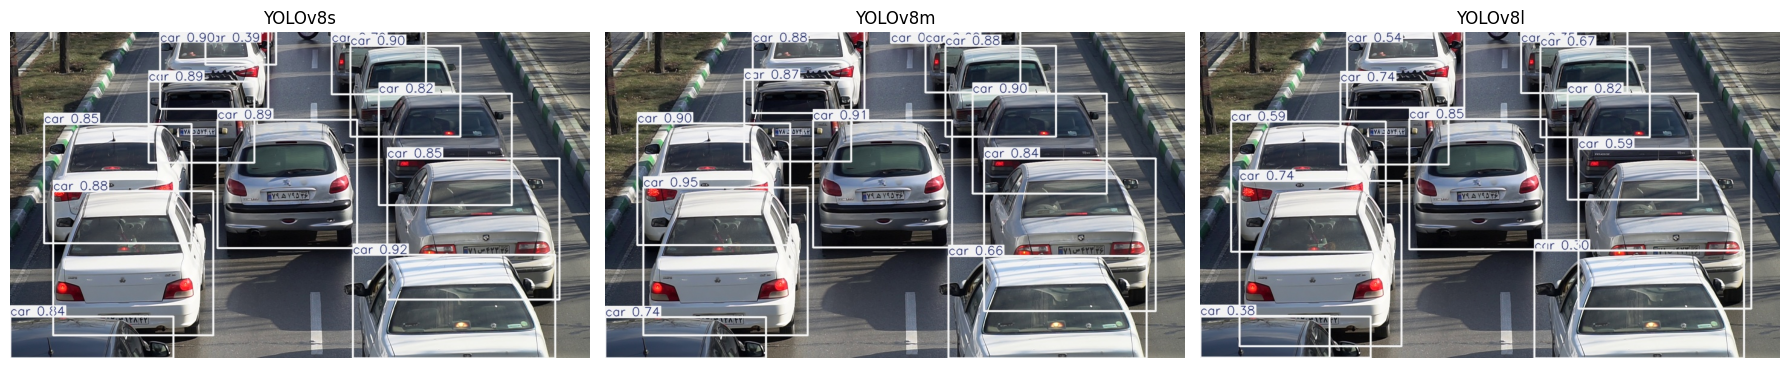

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt
import os

img_s = Image.open(f"/content/drive/MyDrive/VehicleDataset/predictions/YOLOv8s/image43.jpg")
img_m = Image.open(f"/content/drive/MyDrive/VehicleDataset/predictions/YOLOv8m/image43.jpg")
img_l = Image.open(f"/content/drive/MyDrive/VehicleDataset/predictions/YOLOv8l/image43.jpg")

fig, axes = plt.subplots(1, 3, figsize=(18,6))

axes[0].imshow(img_s)
axes[0].set_title("YOLOv8s")
axes[0].axis("off")

axes[1].imshow(img_m)
axes[1].set_title("YOLOv8m")
axes[1].axis("off")

axes[2].imshow(img_l)
axes[2].set_title("YOLOv8l")
axes[2].axis("off")

plt.tight_layout()
plt.show()

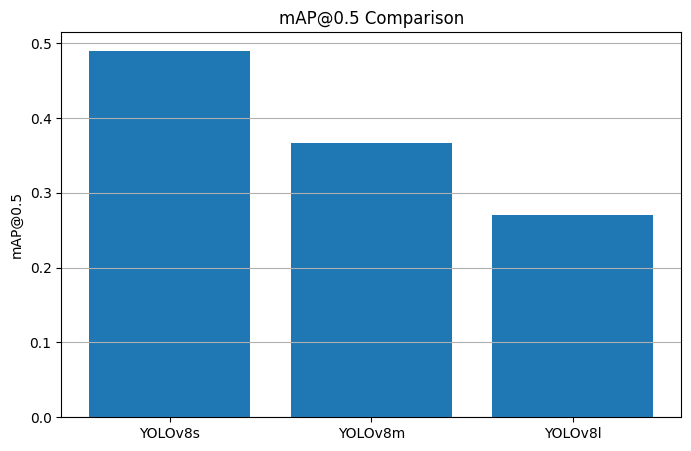

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(comparison["Model"], comparison["mAP@0.5"])

plt.title("mAP@0.5 Comparison")
plt.ylabel("mAP@0.5")
plt.grid(axis="y")

plt.savefig(
    "/content/drive/MyDrive/VehicleDataset/map_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
from IPython.display import Image


Image(filename="/content/drive/MyDrive/VehicleDataset/runs/YOLOv8s/val_batch0_pred.jpg")

# For future work

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
model = YOLO("/content/drive/MyDrive/VehicleDataset/runs/YOLOv8s/weights/best.pt")
model = YOLO("/content/drive/MyDrive/VehicleDataset/runs/YOLOv8m/weights/best.pt")
model = YOLO("/content/drive/MyDrive/VehicleDataset/runs/YOLOv8l/weights/best.pt")